In [15]:
import  numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.svm import SVC

In [2]:
from sklearn.model_selection import train_test_split

In [4]:
from sklearn.datasets import make_classification

In [7]:
x,y=make_classification(n_samples=1000,n_features=2,n_classes=2,n_clusters_per_class=2,n_redundant=0)

In [8]:
x

array([[-2.5935286 ,  1.82196678],
       [-1.26761069,  2.53947805],
       [-1.6920699 ,  2.10587938],
       ...,
       [ 1.10322782, -1.07579609],
       [ 2.63147516, -0.25052296],
       [ 2.75087591, -0.86519522]])

In [9]:
y

array([0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0,
       1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1,
       1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0,
       1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1,
       1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0,
       1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1,
       1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1,
       0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0,
       0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1,
       0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0,

<Axes: xlabel='0', ylabel='1'>

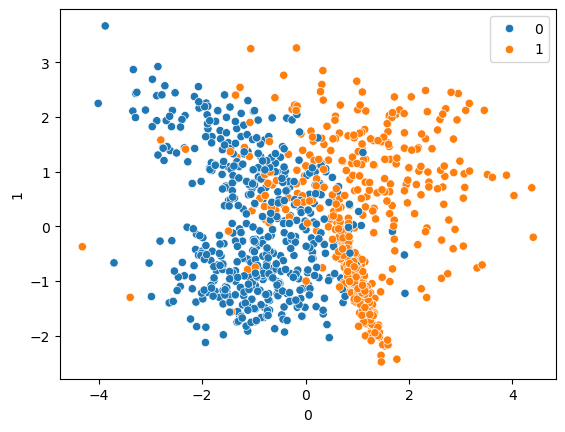

In [12]:
sns.scatterplot(x=pd.DataFrame(x)[0] ,y=pd.DataFrame(x)[1],hue=y)

In [13]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state =10)

In [16]:
 model = SVC(kernel="linear")

In [18]:
model.fit(x_train,y_train)

SVC(kernel='linear')

In [19]:
y_pred=model.predict(x_test)

In [21]:
from sklearn.metrics import confusion_matrix,accuracy_score,classification_report
print(confusion_matrix(y_pred,y_test))
print(accuracy_score(y_pred,y_test))
print(classification_report(y_pred,y_test))

[[111   9]
 [ 14 116]]
0.908
              precision    recall  f1-score   support

           0       0.89      0.93      0.91       120
           1       0.93      0.89      0.91       130

    accuracy                           0.91       250
   macro avg       0.91      0.91      0.91       250
weighted avg       0.91      0.91      0.91       250



In [23]:
best_param={"C":[0.1,1,10,100,1000],
            "gamma":[1,0.1,0.01,0.001,0.0001],
            "kernel":["linear"]
}

In [24]:
from sklearn.model_selection import GridSearchCV

In [25]:
grid = GridSearchCV(model,param_grid=best_param,refit = True,cv=5)

In [26]:
grid.fit(x_train,y_train)

GridSearchCV(cv=5, estimator=SVC(kernel='linear'),
             param_grid={'C': [0.1, 1, 10, 100, 1000],
                         'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
                         'kernel': ['linear']})

In [27]:
grid.best_params_

{'C': 10, 'gamma': 1, 'kernel': 'linear'}